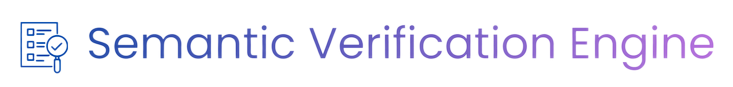

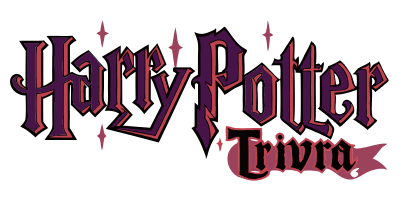

<div style="background-color: #f0e6f7; padding: 8px;">
    <h3 style="text-align:center; color:purple;">Phase 2: Descriptive Featues & Tracer Dataset Status Dashboard </h3>
</div>

# Introduction

This is a **Semantic Verification Engine (SVE)** currently demonstrated through a *Harry Potter trivia game* 🪄. It demonstrates AI system design where **correctness, latency, and cost predictability** are the key drivers (e.g. medical Q&A, compliance training, or certification exams). 

Traditional trivia engines rely on brittle exact-match strings (e.g. answer == "Severus Snape"). A semantic evaluator is required To allow for natural human variation, spelling errors, and multi-clause explanatory answers. This notebook documents the prototyping, testing, and optimization of hybrid Natural Language Processing (NLP) engines designed to evaluate open-ended user trivia answers.

The *Context Refinery* subsystem is the feature enrichment layer. It recieves the Gold dataset from the upstream *Content Factory* (data generation / medallion validation and upgrade). 

In section 1, the [descriptive featues](#1-addition-of-descriptive-features-to-gold-dataset) are added to the Gold Tracer dataset that will be used by the runtime answer evaluators:
- 1.1. [*Length Metrics*](#11-length-metrics): question and answer lengths
- 1.2. [*Answer Types*](#12-answer-types): answers categorized as *text, numeric, date, year* types.
- 1.3. [*Interrogative Keyword*](#13-interrogative-main-keyword): categoraize questions by the main interrogative

Domain-aware contextual features addition with NER is defferred to after the Tracer run to maintain momentum.

Section 2 provides the [*status dashboard of Tracer Gold dataset*](#2-dashboard-of-gold-tracer-v1-dataset) for a baseline profile of the data.

### Imports and setup

In [1]:
#  STANDARD NOTEBOOK SETUP
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')
# --- Core Libraries ---
import pandas as pd
%matplotlib inline

# --- Project-Specific Imports ---
import ds_utils.notebook_config as nb_cfg
import ds_utils.tracer_descp_features_v0 as des
from ds_utils.ds_constants import ANSWER_CATEGORIES
# custom tokenizer from project ds utils
from ds_utils.text_processing import tokenize_text

# --- Common Settings ---
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)

✅ Notebook config loaded.


**Upload the Gold dataset**:

In [2]:
# load the legacy and synthetic tracer datasets
filename = "dataframe_nb7-2_gold_tracer_v1.parquet"
gold_df = pd.read_parquet(nb_cfg.INTERMEDIATE_DATA_DIR / filename)

In [3]:
# Gold Tracer dataset v1 (legacy + synthetic)
gold_df.info()
print("\n","-"*50,"\n Count of Question Types:\n")
print(gold_df.groupby('question_type', observed=True)['question'].size().reset_index(name="count"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   master_id                     139 non-null    object 
 1   original_question_id          104 non-null    float64
 2   syn_id                        35 non-null     object 
 3   question_source               139 non-null    object 
 4   question_type                 139 non-null    object 
 5   question                      139 non-null    object 
 6   answer                        139 non-null    object 
 7   mcq_options                   45 non-null     object 
 8   source_reference              35 non-null     object 
 9   source_quote                  35 non-null     object 
 10  hint_1                        139 non-null    object 
 11  hint_2                        139 non-null    object 
 12  hint_3                        139 non-null    object 
 13  expla

The tracer gold dataset has 139 questions, which are almost evenly split among the three question types: Explanatory (EX), Factual Recall (FR), and Multiple Choice Questions (MCQ) by design.

# 1: Addition of descriptive features to Gold dataset

**Features to add:**

1. **Length Metrics (`question_length`, `answer_length`)**: Word counts for questions and answers providing baseline measures of complexity.
2. **Answer Typing (`answer_type`)**: Classify each answer as text, numeric, date, or year. This allows the answer checker to handle different data formats intelligently (e.g. handling date variations or accepting "fourteen" for "14" from players).
3. **Main interrogative keyword (`main_keyword`)**: used to sub-categorize questions within `question_types` to assess data health (e.g. skewness -> dataset leans towards a specific keyword / question type limits variability and game experience). It can also help with routing logic in the answer grading logic.

In [4]:
# global random state
RANDOM_SEED = 26

# create working copy of tracer df
df = gold_df.copy()

## 1.1: Length metrics
Adding word count columns for the question and its answer.

In [5]:
## Add word counts for question and answer columns
df['question_length'] = des.get_clean_word_counts(df, 'question')
df['answer_length'] = des.get_clean_word_counts(df, 'answer')

## sanity check 1: 
# 1. Type check: Ensure the helper returned integers, not floats or weird objects
assert pd.api.types.is_integer_dtype(df['question_length']), "question_length is not an integer!"
assert pd.api.types.is_integer_dtype(df['answer_length']), "answer_length is not an integer!"

# 2. Null check: Ensure the helper didn't accidentally wipe out data
assert df['question_length'].notna().all(), "Found missing values in question_length!"

# 3. Logic Check: Every question/answer must have at least one word
assert df['question_length'].min() > 0, "Found a question with 0 words!"
assert df['answer_length'].min() > 0, "Found an answer with 0 words!"

# sanity check 2 - visual review
df[['question','question_length','answer','answer_length']].head()

,question,question_length,answer,answer_length
0,Which of these titles or identities has NOT be...,13,spew treasurer,2
1,Which of the following spells is considered on...,25,crucio,1
2,In which of these scenarios would you use the ...,11,whispering in the library without being overheard,7
3,Which one of the following is not a founder of...,11,helena ravenclaw,2
4,Which of these factors does NOT affect Transfi...,8,hue of the object,4


>**Note: NLP tokenization vs. word count**
>
>The `question_length` and `answer_length` features are calculated using a strict regex tokenization approach (`\b\w+\b`) rather than a naive space-delimited string split (`.split()`). This is an **intentional design choice** to prepare the dataset for the downstream NLP routing engine. Advanced ML models treat punctuation boundaries (like hyphens and apostrophes) as distinct tokens. 
>
>**How this affects the counts:**
>* *Standard `.split()`:* `"What is Harry's wand-core?"` $\rightarrow$ **4 words**
>* *Our NLP Helper:* `"What is Harry's wand-core?"` $\rightarrow$ **6 tokens** (`['What', 'is', 'Harry', 's', 'wand', 'core']`)
>
>If you spot-check the data and notice the length columns are slightly higher than a visual word count, **this is not an error.** It accurately reflects the semantic token load of the text, correctly handling possessives (e.g., "Philosopher's") and hyphenated entities (e.g., "advanced-level").
>
>**Occurences within dataset are demonstrated below:**

In [6]:
# create the baseline (naive split)
baseline_lengths = df['question'].apply(lambda x: len(str(x).split()))

# filter the dataframe to show where counts dont match with baseline (naive) count
mismatches = df[df['question_length'] != baseline_lengths]

# display mismatches
display(mismatches[['master_id','question', 'question_length']].head())

,master_id,question,question_length
15,5ljRL2JJ,According to the description from Professor Sl...,17
16,pGFZQDF_,"What are the final, advanced-level exams that ...",20
25,YrHLNT5a,What was the number of the high-security Gring...,17
26,qWMHzSpQ,Albus Dumbledore is famous for discovering how...,13
28,JzJvhttw,"In Harry Potter and the Philosopher's Stone, h...",18


>These counts are correct.
>- **id. pGFZQDF_:** correctly counts "advanced-level" as two words.
>- **id. 5ljRL2JJ**: splits "Slughorn's" at the apostrophe into "Slughorn" and "s" and counts both.

## 1.2: Answer types

Adding the `answer_type` column with four categories:
- text,
- numeric,
- date,
- year

In [7]:
# classify the remaining questions into 'numeric', 'date', 'year', 'text', into a new column 'answer_type' 
# using the custom function from eda_scripts
df['answer_type'] = df.apply(des.classify_answer_type, axis=1)

# convert column to category
df['answer_type'] = pd.Categorical(df['answer_type'], 
                                   categories=ANSWER_CATEGORIES, 
                                   ordered=False)

# sanity check 1: visual review
df[['question_type','question','answer','answer_type']].groupby('answer_type', observed=True).head(2)

,question_type,question,answer,answer_type
0,MCQ,Which of these titles or identities has NOT be...,spew treasurer,text
1,MCQ,Which of the following spells is considered on...,crucio,text
25,MCQ,What was the number of the high-security Gring...,713,numeric
26,MCQ,Albus Dumbledore is famous for discovering how...,12,numeric
65,FR,When was Azkaban Prison established?,1718,year
66,FR,When was the first full description of the gam...,1398,year
70,FR,On what chilling date did baby Harry Potter mi...,"halloween (or october 31st), 1981",date
71,FR,What day did James and Lily Potter die?,october 31,date


In [8]:
# sanity checks 2:
expected_answer_types = set(ANSWER_CATEGORIES)

# null check
assert df['answer_type'].notna().all(), "CRITICAL: Found Null (NaN) values in answer_type"
# type check: Ensure the column is strictly text/strings
assert pd.api.types.is_string_dtype(df['answer_type']), "CRITICAL: answer_type column is not a string type!"
# empty string check
assert (df['answer_type'].str.strip() != "").all(), "CRITICAL: Found empty strings in answer_type!"
# vocab check: Did the script output any unexpected categories or typos?
actual_answer_types = set(df['answer_type'].unique())
unrecognized_types = actual_answer_types - expected_answer_types
assert not unrecognized_types, f"CRITICAL: Found unexpected answer types: {unrecognized_types}"

print("Answer Type sanity checks passed: Categories are valid, complete, and strictly enforced.")

Answer Type sanity checks passed: Categories are valid, complete, and strictly enforced.


## 1.3: Interrogative main keyword

In [9]:
# create temporary token columns to create main_keyword column
df = des.create_token_columns(df, tokenizer=tokenize_text)
df[['master_id','question','answer','question_tokens', 'answer_tokens','combined_unique_tokens']]

,master_id,question,answer,question_tokens,answer_tokens,combined_unique_tokens
0,RrQ-KzTp,Which of these titles or identities has NOT be...,spew treasurer,"[which, title, identity, have, be, hold, harry...","[spew, treasurer]","[which, title, identity, have, be, hold, harry..."
1,mK7xFxiU,Which of the following spells is considered on...,crucio,"[which, following, spell, be, consider, one, t...",[crucio],"[which, following, spell, be, consider, one, t..."
2,Rv-Itd0C,In which of these scenarios would you use the ...,whispering in the library without being overheard,"[which, scenario, would, use, muffliato, charm]","[whisper, library, without, be, overheard]","[which, scenario, would, use, muffliato, charm..."
3,txOZUZVs,Which one of the following is not a founder of...,helena ravenclaw,"[which, one, following, be, founder, hogwarts]","[helena, ravenclaw]","[which, one, following, be, founder, hogwarts,..."
4,6rNntS3I,Which of these factors does NOT affect Transfi...,hue of the object,"[which, factor, do, affect, transfiguration]","[hue, object]","[which, factor, do, affect, transfiguration, h..."
...,...,...,...,...,...,...
134,KLGMCCkE,What crucial secret did Dumbledore reveal to S...,that a fragment of voldemort's soul resided wi...,"[what, crucial, secret, do, dumbledore, reveal...","[fragment, voldemort, soul, reside, within, ha...","[what, crucial, secret, do, dumbledore, reveal..."
135,Y--cqa16,Who carried Colin Creevey's body from the grou...,oliver wood,"[who, carry, colin, creevey, body, ground, bat...","[oliver, wood]","[who, carry, colin, creevey, body, ground, bat..."
136,u77nA0FB,What creature did Harry instruct Neville Longb...,nagini,"[what, creature, do, harry, instruct, neville,...",[nagini],"[what, creature, do, harry, instruct, neville,..."
137,_NlWzmGZ,How did Sirius Black describe the experience o...,quicker and easier than falling asleep,"[how, do, sirius, black, describe, experience,...","[quicker, easy, fall, asleep]","[how, do, sirius, black, describe, experience,..."


In [10]:
# add `main_keyword` column
df['main_keyword'] = df['question_tokens'].apply(des.extract_main_keyword)

#sanity check 1: visual check
df[['master_id','question','answer','question_tokens','main_keyword']].sample(5,random_state=RANDOM_SEED)

,master_id,question,answer,question_tokens,main_keyword
72,8eVyidSE,What is Snape's birthday?,"january 9, 1960","[what, be, snape, birthday]",what
21,NB0toJDa,Which of the following is NOT a form of Transf...,enchantment,"[which, following, be, form, transfiguration]",which
118,kFTWJTxO,Why did Lord Voldemort not recognize the Resur...,voldemort did not value or comprehend the true...,"[why, do, lord, voldemort, recognize, resurrec...",why
101,6ev09EVV,Which of these is not a species of dragon:,finnish flamethrower,"[which, be, specie, dragon]",which
89,ZOkIPD70,Who does Harry live with before going to Hogwa...,"his aunt and uncle, petunia and vernon dursley...","[who, do, harry, live, go, hogwarts]",who


In [11]:
# sanity check 2: No NaN values accidentally created during the feature extraction
assert df['question_length'].notna().all(), "CRITICAL: Missing values in question_length!"
assert df['main_keyword'].notna().all(), "CRITICAL: Missing values in main_keyword!"

# 2: Dashboard of Gold Tracer v1 dataset

Full tracer dataset (legacy and synthetic) dashboard provides a summary of key metrics of the validated Gold dataset. The tracer dataset contains strategically sampled legacy dataset (phase 1 cleaned validated HF dataset) and synthetically questions generated by an LLM in the offline *SVE Content Factory*.

## 📊 Trivia Dataset Status Map

---

### 1. Key Metrics

**- Total Unique Questions:** 139<br>**- Answer Type Distribution:** text (119), numeric (10), date (5), year (5)<br>


### 2. Breakdown by Question Type

,Question Count,Percentage (%),Unique Answer Count,Median Q Len,Median A Len,Top Answer Keywords,Top main_keyword,Unassigned Keyword Count
Question Type,,,,,,,,
FR,49,35.3%,49,10.0,2.0,"october (2), 31 (2), potter (2)","what (14), when (10), which (7)",0
EX,45,32.4%,45,17.0,20.0,"voldemort (11), dumbledore (8), harry (6)","why (16), how (13), what (9)",0
MCQ,45,32.4%,45,12.0,2.0,"spew (1), treasurer (1), crucio (1)","which (22), what (13), how (5)",0



Note: FR (Factual Recall), EX (Explanatory), YN (Yes/No or True/False), MCQ (Multiple Choice)



### 3. Visualizations by Question Type

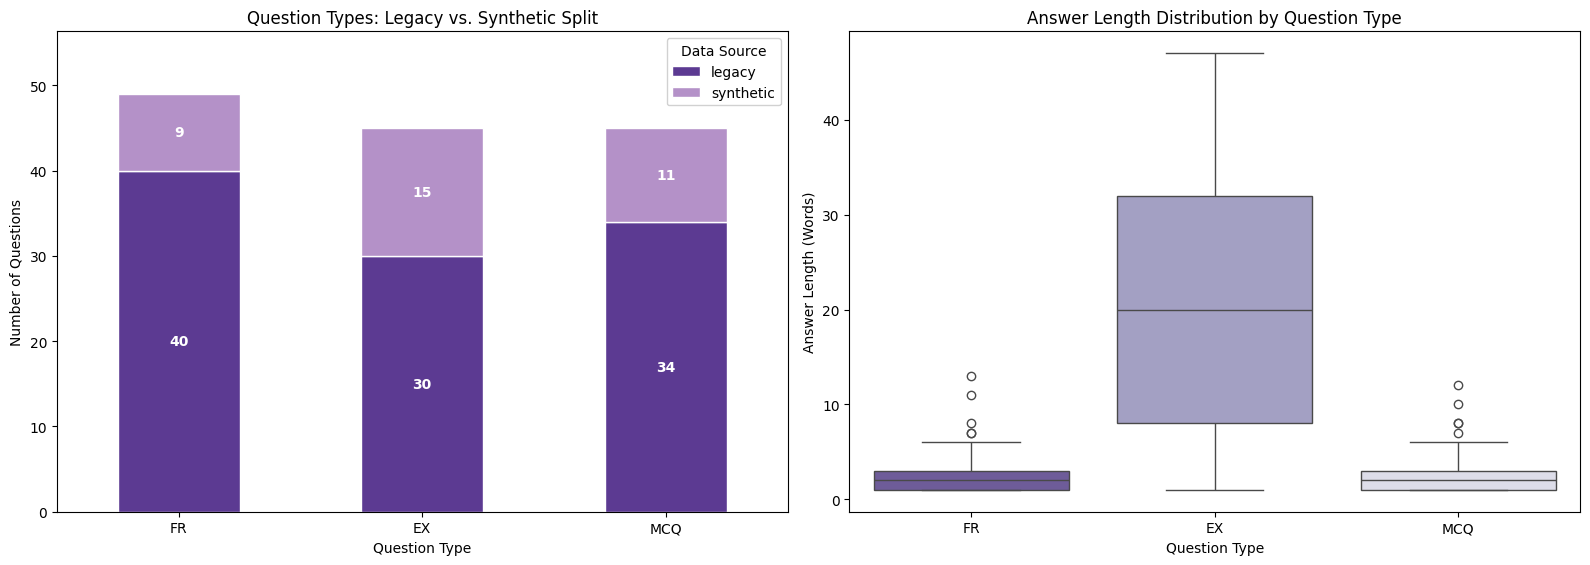


### 📚 Source Text Ingestion Map

,Total_Questions,Chapters_Ingested,Heaviest Chapters (Count)
Book,,,
Legacy Data,104,0,
deathly_hallows,35,6,"Chapter 31 (8), Chapter 35 (8)"



---

In [12]:
des.generate_dataset_status_report(df)

In [13]:
# 💾 Checkpoint: Notebook 8 output dataframe 

output_path = nb_cfg.INTERMEDIATE_DATA_DIR / "dataframe_nb8_context_refinery_new_desc_cols.parquet"

if not output_path.exists():
    print(f"File not found. Saving data to {output_path.name}...")
    df.to_parquet(output_path)
else:
    print(f"File {output_path.name} already exists. Skipping save.")

File not found. Saving data to dataframe_nb8_context_refinery_new_desc_cols.parquet...
